<a href="https://colab.research.google.com/github/mnlslzr/Clasificador_de_arritmias/blob/master/Pruebav2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
Procesando registro 100...
Procesando registro 101...
Procesando registro 102...
Procesando registro 103...
Procesando registro 104...
Procesando registro 105...
Procesando registro 106...
Procesando registro 107...
Procesando registro 108...
Procesando registro 109...
Procesando registro 1

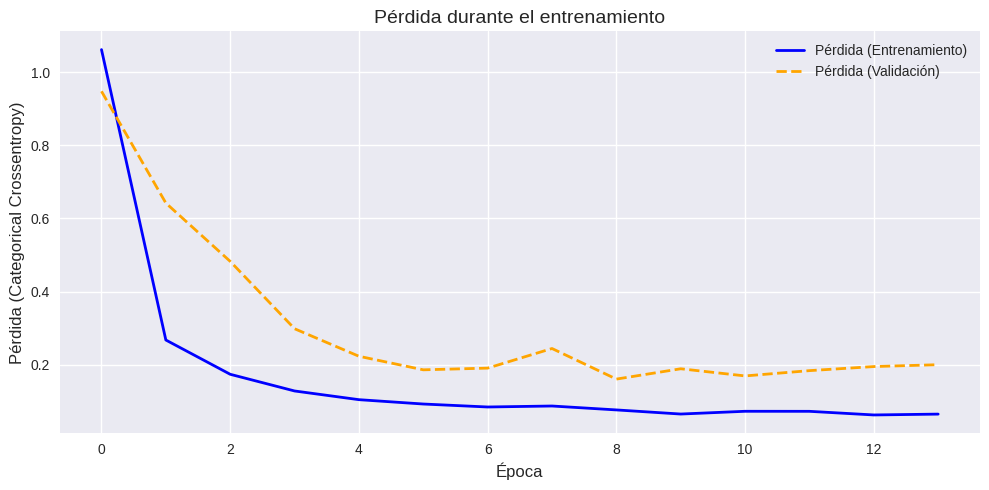

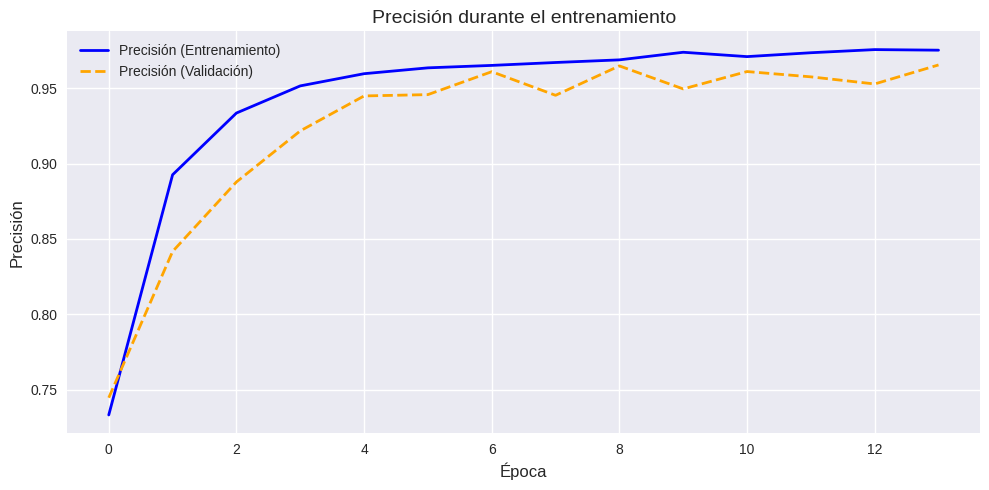

704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

           F       0.19      0.97      0.32       160
           N       1.00      0.92      0.96     18070
           Q       0.91      0.99      0.95      2309
           S       0.47      0.97      0.63       526
           V       0.91      0.94      0.93      1447

    accuracy                           0.93     22512
   macro avg       0.69      0.96      0.75     22512
weighted avg       0.97      0.93      0.94     22512


Predicciones para 'N' (primeras 10): [9.6203488e-01 9.9999952e-01 9.9998909e-01 6.7474764e-05 9.9994940e-01
 8.6804521e-01 9.9956489e-01 9.9851853e-01 9.9993783e-01 9.9999875e-01]
Min: 0.0000, Max: 1.0000, Mean: 0.7329

Clases en test: ['F' 'N' 'Q' 'S' 'V']
AUC F: 0.9947
AUC N: 0.9951
AUC Q: 0.9978
AUC S: 0.9959
AUC V: 0.9943


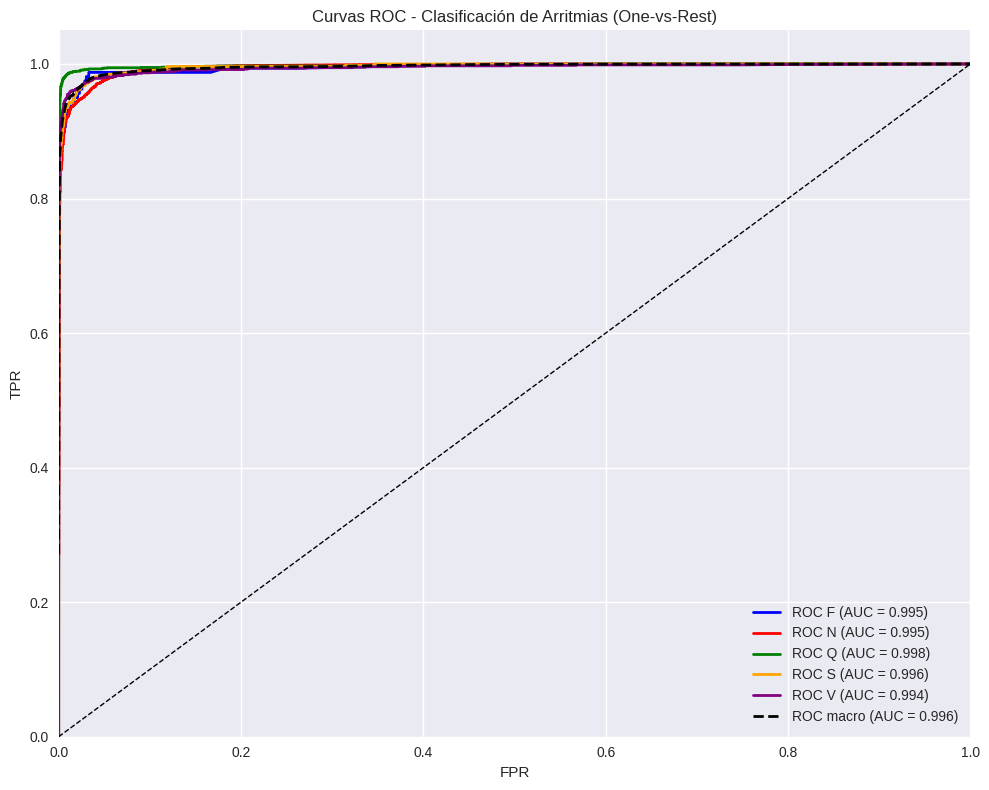

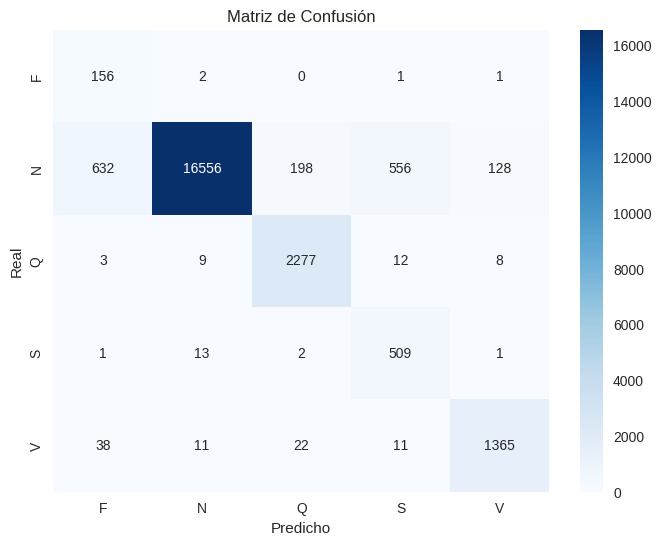

In [1]:
!pip install wfdb scipy numpy tensorflow scikit-learn matplotlib imblearn seaborn -q

import numpy as np
import wfdb
from scipy.signal import resample, butter, filtfilt, iirnotch
from sklearn.preprocessing import LabelEncoder, label_binarize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input, UpSampling1D
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")

# --- Funciones de preprocesamiento ---
def filtro_pasa_banda(senal, fs, lowcut=0.5, highcut=40.0, orden=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(orden, [low, high], btype='band')
    return filtfilt(b, a, senal)

def filtro_notch(senal, fs, freq_notch=60.0, Q=30.0):
    w0 = freq_notch / (fs / 2)
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, senal)

def normalizar_segmento(segmento):
    min_val = np.min(segmento)
    max_val = np.max(segmento)
    if max_val == min_val:
        return segmento - min_val
    return (segmento - min_val) / (max_val - min_val)

def ajustar_frecuencia(senal, frecuencia_original, frecuencia_deseada=360):
    if frecuencia_original == frecuencia_deseada:
        return senal
    num_muestras_nuevo = int(len(senal) * frecuencia_deseada / frecuencia_original)
    return resample(senal, num_muestras_nuevo)

def segmentar_y_normalizar(senal, picos, tamano_ventana=256):
    segmentos = []
    indices_validos = []
    for i, pico in enumerate(picos):
        inicio = pico - tamano_ventana // 2
        fin = pico + tamano_ventana // 2
        if inicio >= 0 and fin <= len(senal):
            segmento = senal[inicio:fin]
            if len(segmento) == tamano_ventana:
                segmento_norm = normalizar_segmento(segmento)
                segmentos.append(segmento_norm)
                indices_validos.append(i)
    return np.array(segmentos), indices_validos

# --- Cargar y procesar MIT-BIH ---
registros = [str(i) for i in range(100, 235)]
segmentos_total = []
etiquetas_total = []
frecuencia_mit = 360

for reg in registros:
    try:
        print(f"Procesando registro {reg}...")
        record_mit = wfdb.rdrecord(reg, pn_dir='mitdb/')
        annotation_mit = wfdb.rdann(reg, extension='atr', pn_dir='mitdb/')
        senal_mit = record_mit.p_signal[:, 0]
        picos_mit = annotation_mit.sample
        etiquetas_mit = annotation_mit.symbol
        senal_mit_ajustada = ajustar_frecuencia(senal_mit, frecuencia_mit)
        senal_mit_filtrada = filtro_pasa_banda(senal_mit_ajustada, fs=frecuencia_mit)
        senal_mit_filtrada = filtro_notch(senal_mit_filtrada, fs=frecuencia_mit)
        segmentos_reg, indices_validos = segmentar_y_normalizar(senal_mit_filtrada, picos_mit)
        etiquetas_reg = [etiquetas_mit[i] for i in indices_validos]
        segmentos_total.extend(segmentos_reg)
        etiquetas_total.extend(etiquetas_reg)
    except Exception as e:
        print(f"Error al procesar registro {reg}: {str(e)}")
        continue

segmentos_total = np.array(segmentos_total)
etiquetas_total = np.array(etiquetas_total)
print(f"Total de segmentos procesados: {len(segmentos_total)}")

# --- Agrupar etiquetas AAMI ---
mapeo_aami = {
    'N': 'N', 'L': 'N', 'R': 'N',
    'A': 'S', 'S': 'S', 'J': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    'Q': 'Q', 'f': 'Q', '/': 'Q', '+': 'Q'
}
etiquetas_aami = [mapeo_aami.get(e, 'Q') for e in etiquetas_total]
print("Distribución de clases AAMI:", Counter(etiquetas_aami))

# --- Codificar etiquetas ---
codificador = LabelEncoder()
etiquetas_numeros = codificador.fit_transform(etiquetas_aami)
etiquetas_onehot = to_categorical(etiquetas_numeros)

# --- Pesos de clase ---
pesos = class_weight.compute_class_weight('balanced', classes=np.unique(etiquetas_numeros), y=etiquetas_numeros)
pesos_dict = dict(enumerate(pesos))
print("Pesos de clases:", {codificador.classes_[k]: round(v, 3) for k, v in pesos_dict.items()})

# --- Autoencoder ---
input_shape = (256, 1)
input_signal = Input(shape=input_shape)

# Encoder
x = Conv1D(32, kernel_size=5, activation='relu', padding='same')(input_signal)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(16, kernel_size=5, activation='relu', padding='same')(x)
encoded = MaxPooling1D(pool_size=2)(x)

# Decoder
x = Conv1D(16, kernel_size=5, activation='relu', padding='same')(encoded)
x = UpSampling1D(size=2)(x)
x = Conv1D(32, kernel_size=5, activation='relu', padding='same')(x)
x = UpSampling1D(size=2)(x)
decoded = Conv1D(1, kernel_size=3, activation='linear', padding='same')(x)

autoencoder = Model(input_signal, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
encoder = Model(input_signal, encoded)

# Entrenar autoencoder
X_auto = segmentos_total[..., np.newaxis]
X_train_auto, X_val_auto = train_test_split(X_auto, test_size=0.2, random_state=42)
autoencoder.fit(X_train_auto, X_train_auto, epochs=20, batch_size=32, validation_data=(X_val_auto, X_val_auto), verbose=1)

# Extraer representaciones
encoded_segments = encoder.predict(X_auto)
print("Forma de las representaciones latentes:", encoded_segments.shape)

# --- SPLIT CON STRATIFY ---
X_train, X_test, y_train, y_test = train_test_split(
    encoded_segments, etiquetas_onehot,
    test_size=0.2, random_state=42,
    stratify=etiquetas_numeros
)

# --- SMOTE SOLO EN ENTRENAMIENTO ---
print("\nAplicando SMOTE en entrenamiento...")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
y_train_labels = np.argmax(y_train, axis=1)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_flat, y_train_labels)

X_train_res = X_train_res.reshape(-1, X_train.shape[1], X_train.shape[2])
y_train_res = to_categorical(y_train_res, num_classes=len(codificador.classes_))

print(f"Después de SMOTE: {X_train_res.shape[0]} ejemplos")

# --- Modelo híbrido ---
modelo_hibrido = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(encoded_segments.shape[1], encoded_segments.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128, return_sequences=False),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(codificador.classes_), activation='softmax')
])

modelo_hibrido.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- Early Stopping ---
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --- Entrenar ---
historia = modelo_hibrido.fit(
    X_train_res, y_train_res,
    epochs=50, batch_size=32,
    validation_split=0.2,
    class_weight=pesos_dict,
    callbacks=[early_stopping],
    verbose=1
)

# --- GRAFICAS DE PÉRDIDA Y PRECISIÓN (como antes) ---
plt.style.use('seaborn-v0_8')

# Gráfica de pérdida
plt.figure(figsize=(10, 5))
plt.plot(historia.history['loss'], label='Pérdida (Entrenamiento)', color='blue', linewidth=2)
plt.plot(historia.history['val_loss'], label='Pérdida (Validación)', color='orange', linestyle='--', linewidth=2)
plt.title('Pérdida durante el entrenamiento', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Pérdida (Categorical Crossentropy)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/perdida.png')
plt.show()

# Gráfica de precisión
plt.figure(figsize=(10, 5))
plt.plot(historia.history['accuracy'], label='Precisión (Entrenamiento)', color='blue', linewidth=2)
plt.plot(historia.history['val_accuracy'], label='Precisión (Validación)', color='orange', linestyle='--', linewidth=2)
plt.title('Precisión durante el entrenamiento', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/precision.png')
plt.show()

# --- Evaluar ---
y_pred = modelo_hibrido.predict(X_test)
y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
row_sums = y_pred.sum(axis=1, keepdims=True)
y_pred = y_pred / row_sums

y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("\nReporte de clasificación:")
print(classification_report(y_test_classes, y_pred_classes, target_names=codificador.classes_))

# --- DIAGNÓSTICO DE 'N' ---
n_idx = list(codificador.classes_).index('N')
print(f"\nPredicciones para 'N' (primeras 10): {y_pred[:10, n_idx]}")
print(f"Min: {y_pred[:, n_idx].min():.4f}, Max: {y_pred[:, n_idx].max():.4f}, Mean: {y_pred[:, n_idx].mean():.4f}")

# --- CURVAS ROC ROBUSTAS ---
present_classes = np.unique(y_test_classes)
print(f"\nClases en test: {codificador.classes_[present_classes]}")

y_test_bin = label_binarize(y_test_classes, classes=present_classes)
y_pred_present = y_pred[:, present_classes]

fpr, tpr, roc_auc = {}, {}, {}
for i, cls_idx in enumerate(present_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_present[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f"AUC {codificador.classes_[cls_idx]}: {roc_auc[i]:.4f}")

# Macro AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(present_classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(present_classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(present_classes)
roc_auc_macro = auc(all_fpr, mean_tpr)

# --- Graficar ROC ---
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
for i, color in zip(range(len(present_classes)), colors):
    cls_name = codificador.classes_[present_classes[i]]
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {cls_name} (AUC = {roc_auc[i]:.3f})')

plt.plot(all_fpr, mean_tpr, color='black', lw=2, linestyle='--',
         label=f'ROC macro (AUC = {roc_auc_macro:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC - Clasificación de Arritmias (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/curvas_roc_final.png')
plt.show()

# --- Matriz de confusión ---
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=codificador.classes_, yticklabels=codificador.classes_)
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.savefig('/content/matriz_confusion.png')
plt.show()